In [1]:
import pandas as pd
import numpy as np


In [4]:
# Load dataset
dataset = pd.read_csv('Data/twitchdata.csv')
dataset

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
...,...,...,...,...,...,...,...,...,...,...,...
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English


In [21]:
# Rename columns 
dataset = dataset.rename(columns={
    'Views gained': 'View_gained',
    'Watch time(Minutes)': 'Watch_time',
    'Stream time(minutes)': 'Stream_time',
    'Peak viewers': 'Peak_viewers',
    'Average viewers': 'Avg_viewers',
    'Followers gained': 'Followers_gained'
    })


In [22]:
# Keep only numeric columns
dataset = dataset.select_dtypes(include=['number'])


In [23]:
# Handle missing values
dataset = data.fillna(data.mean())

In [24]:
# Target
y = dataset['View_gained']

In [25]:
# Features
X = data.drop('View_gained', axis=1)


In [26]:
# Remove outliers (IQR)

def remove_outliers(df):
    clean_df = df.copy()
    for col in df.columns:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]
    return clean_df

data_clean = remove_outliers(data)

# redefine X and y after cleaning
y = data_clean['View_gained']
X = data_clean.drop('View_gained', axis=1)

In [27]:
# Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [28]:
# Models

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

results = []

In [29]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append(['Linear Regression',
                mean_squared_error(y_test, y_pred_lr),
                r2_score(y_test, y_pred_lr)])

In [30]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)

results.append(['Polynomial Regression',
                mean_squared_error(y_test, y_pred_pr),
                r2_score(y_test, y_pred_pr)])

In [31]:
# Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

results.append(['Ridge',
                mean_squared_error(y_test, y_pred_ridge),
                r2_score(y_test, y_pred_ridge)])

In [32]:
# Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

results.append(['Lasso',
                mean_squared_error(y_test, y_pred_lasso),
                r2_score(y_test, y_pred_lasso)])

In [33]:
# Elastic Net
elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

results.append(['Elastic Net',
                mean_squared_error(y_test, y_pred_elastic),
                r2_score(y_test, y_pred_elastic)])


In [34]:
# Compare models

results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'R2'])
print(results_df)

best_model = results_df.loc[results_df['R2'].idxmax()]
print("\nBest Model:", best_model['Model'])

                   Model           MSE        R2
0      Linear Regression  5.950820e+12  0.450933
1  Polynomial Regression  6.258308e+12  0.422562
2                  Ridge  5.950820e+12  0.450933
3                  Lasso  5.950820e+12  0.450933
4            Elastic Net  5.950820e+12  0.450933

Best Model: Elastic Net


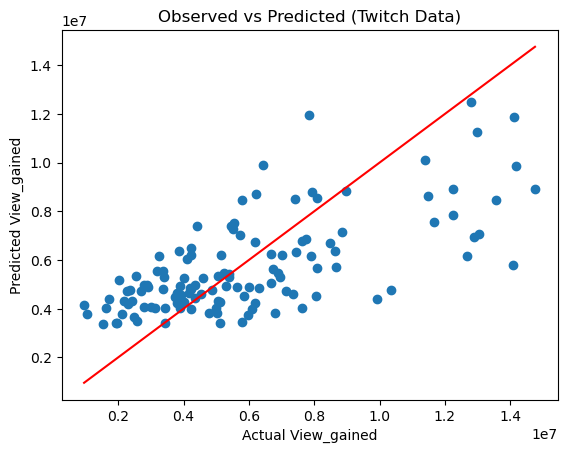

In [35]:
# Visualization

import matplotlib.pyplot as plt

# Use best model predictions
if best_model['Model'] == 'Polynomial Regression':
    y_pred_best = y_pred_pr
else:
    y_pred_best = lr.predict(X_test)

plt.scatter(y_test, y_pred_best)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual View_gained")
plt.ylabel("Predicted View_gained")
plt.title("Observed vs Predicted (Twitch Data)")
plt.show()